# Introduction to Leslie Matrix Models

Imagine you are studying an animal population. You know that birth rates and survival rates often depend heavily on an individual's age. Young individuals might not reproduce yet, prime-age adults might have high birth rates, and older individuals might have lower survival rates. How can you model the *entire* population's growth and structure over time, taking these age differences into account?

This is where the **Leslie Matrix model** comes in. Developed by Patrick H. Leslie in the 1940s, it is a powerful tool in population ecology used to model the growth of populations that are structured by **age classes**. It operates in discrete time steps (e.g. year to year) and uses matrix multiplication to project the future size and age distribution of a population.

Unlike simpler models that treat populations as homogeneous, the Leslie Matrix model incorporates **demographic structure**, recognising that individuals of different ages contribute differently to reproduction and survival.

---

## A Quick Comparison: Logistic Growth vs. Leslie Matrix

To appreciate the usefulness of the Leslie Matrix model, it helps to contrast it with a simpler model.

**Logistic Growth Model** — captures density-dependent growth with a carrying capacity $K$:
$$N_{t+1} = N_t + r N_t \left(1 - \frac{N_t}{K}\right)$$
This model tracks a *single number* — total population size. Every individual is treated identically, regardless of age.

**Leslie Matrix Model** — tracks a *vector* of age-specific counts:
$$\mathbf{n}_{t+1} = \mathbf{L}\, \mathbf{n}_t$$
where $\mathbf{L}$ is the Leslie matrix and $\mathbf{n}_t$ is the population vector at time $t$. This allows detailed modelling of delayed reproduction, age-specific mortality, and long-term age structure.

---

## Core Components

### 1. Population Vector $\mathbf{n}_t$

A column vector with the number of individuals in each of the $k$ age classes at time $t$:
$$\mathbf{n}_t = \begin{bmatrix} n_{1,t} \\ n_{2,t} \\ \vdots \\ n_{k,t} \end{bmatrix}$$

### 2. The Leslie Matrix $\mathbf{L}$

A $k \times k$ square matrix with two types of entries:

- **Fecundity rates $f_i$** — the average number of newborn offspring produced by an individual in age class $i$ that survive to enter age class 1 at the next time step. These fill the **first row**.
- **Survival rates $s_i$** — the probability that an individual in age class $i$ survives to enter age class $i+1$. These fill the **sub-diagonal**.
- All other entries are zero.

$$\mathbf{L} = \begin{bmatrix}
f_1 & f_2 & f_3 & \cdots & f_{k-1} & f_k \\
s_1 & 0   & 0   & \cdots & 0       & 0   \\
0   & s_2 & 0   & \cdots & 0       & 0   \\
\vdots & & \ddots & & & \vdots \\
0   & 0   & 0   & \cdots & s_{k-1} & 0
\end{bmatrix}$$

### 3. The Projection Equation

To project the population forward by one time step:
$$\mathbf{n}_{t+1} = \mathbf{L} \times \mathbf{n}_t$$

Applying this repeatedly gives the population trajectory over many time steps.

---

## Key Assumptions

The basic Leslie Matrix model assumes:
- Individuals are grouped into discrete age classes.
- Time progresses in fixed intervals.
- Birth and survival rates are **constant over time** (this can be relaxed in extensions of the model).
- The model is **linear** — no density dependence.

---
## Example 1: Building a Leslie Matrix Step by Step

Let's model a hypothetical bird population with **three age classes**.

| Age Class | Description   | Fecundity ($f_i$) | Survival ($s_i$) |
|-----------|---------------|-------------------|------------------|
| Class 1   | Juveniles (0–1 yr)     | 0 (no reproduction) | $s_1 = 0.5$ |
| Class 2   | Young Adults (1–2 yr)  | $f_2 = 2.0$ offspring | $s_2 = 0.7$ |
| Class 3   | Mature Adults (2–3 yr) | $f_3 = 1.0$ offspring | — (last class) |

**Initial population at $t=0$:** 10 Juveniles, 8 Young Adults, 5 Mature Adults.

We will build the matrix manually, step by step, so each operation is clear.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 1: Define demographic parameters
# ---------------------------------------------------------
f = np.array([0.0, 2.0, 1.0])   # Fecundity rates for each age class
s = np.array([0.5, 0.7])        # Survival rates  (one fewer than age classes)

k = len(f)                       # Number of age classes
print(f"Number of age classes: {k}")
print(f"Fecundity rates : {f}")
print(f"Survival rates  : {s}")

Number of age classes: 3
Fecundity rates : [0. 2. 1.]
Survival rates  : [0.5 0.7]


In [ ]:
# ---------------------------------------------------------
# Step 2: Construct the Leslie Matrix L
# ---------------------------------------------------------
# Start with an all-zero k x k matrix
L = np.zeros((k, k))

# Fill the first row with fecundity rates
L[0, :] = f

print("Leslie Matrix with Fecundity rates:")
print(L)

Leslie Matrix L:
[[0. 2. 1.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [7]:

# Fill the sub-diagonal with survival rates
# L[i, i-1] = s[i-1]  means "class i-1 survivors move to class i"
for i in range(1, k):
    L[i, i - 1] = s[i - 1]

print("Finished Leslie Matrix L:")
print(L)

Finished Leslie Matrix L:
[[0.  2.  1. ]
 [0.5 0.  0. ]
 [0.  0.7 0. ]]


In [ ]:
# ---------------------------------------------------------
# Step 3: Define the initial population vector N0
# ---------------------------------------------------------
N0 = np.array([10.0, 8.0, 5.0])  # [Juveniles, Young Adults, Mature Adults]

print("Initial population vector N0:")
print(N0)
print(f"  Juveniles     (class 1): {int(N0[0])}")
print(f"  Young Adults  (class 2): {int(N0[1])}")
print(f"  Mature Adults (class 3): {int(N0[2])}")
print(f"  Total                  : {int(N0.sum())}")

Initial population vector N0:
  Juveniles     (class 1): 10
  Young Adults  (class 2): 8
  Mature Adults (class 3): 5
  Total                  : 23


In [11]:
# ---------------------------------------------------------
# Step 4: Project the population one time step forward
#   N1 = L @ N0
# ---------------------------------------------------------
N1 = L @ N0   # The @ operator performs matrix-vector multiplication
print("Population at step 1 (N1):")
print(N1)
print("Population after one time step (N1 = L @ N0):")
print(f"  Juveniles     (class 1): {N1[0]:.1f}")
print(f"  Young Adults  (class 2): {N1[1]:.1f}")
print(f"  Mature Adults (class 3): {N1[2]:.1f}")
print(f"  Total                  : {N1.sum():.1f}")


Population at step 1 (N1):
[21.   5.   5.6]
Population after one time step (N1 = L @ N0):
  Juveniles     (class 1): 21.0
  Young Adults  (class 2): 5.0
  Mature Adults (class 3): 5.6
  Total                  : 31.6


In [ ]:
N2 = L @ N1  # The @ operator performs matrix-vector multiplication
print("Population at step 2 (N2):")
print(N2)

Population at step 1 (N1):
[15.6 10.5  3.5]


In [ ]:
N3 = L @ N3  # The @ operator performs matrix-vector multiplication
print("Population at step 2 (N2):")
print(N3)

---
## Example 2: Simulating Population Growth Over Many Time Steps

A single projection gives us the next year. To understand long-term dynamics, we need to apply the projection equation repeatedly:

$$\mathbf{n}_1 = \mathbf{L}\,\mathbf{n}_0 \quad \Rightarrow \quad \mathbf{n}_2 = \mathbf{L}\,\mathbf{n}_1 \quad \Rightarrow \quad \cdots$$

Let's use a slightly different bird population scenario and simulate it for 20 years:

| Age Class | Description       | Fecundity | Survival |
|-----------|-------------------|-----------|----------|
| Class 1   | Chicks (0–1 yr)   | 0         | $s_1 = 0.6$ |
| Class 2   | Young Adults      | $f_2 = 1.5$ | $s_2 = 0.5$ |
| Class 3   | Older Adults      | $f_3 = 2.0$ | — |

**Initial population:** 100 Chicks, 0 Adults.

In [19]:
# ---------------------------------------------------------
# Define parameters for this scenario
# ---------------------------------------------------------
F1, F2, F3 = 0.0, 1.1, 1.6   # Fecundity rates
S1, S2     = 0.6, 0.5         # Survival rates

L_sim = np.array([[F1, F2, F3],
                  [S1,  0,  0],
                  [ 0, S2,  0]])

print("Leslie Matrix for this scenario:")
print(L_sim)

Leslie Matrix for this scenario:
[[0.  1.1 1.6]
 [0.6 0.  0. ]
 [0.  0.5 0. ]]


In [20]:
# ---------------------------------------------------------
# Set up initial population and storage
# ---------------------------------------------------------
n0_sim = np.array([100.0, 0.0, 0.0])  # Only chicks at t=0
years  = 20

# pop_history[:,t] will hold the population vector at year t
# Shape: (3 age classes) x (21 time points: t=0..20)
pop_history = np.zeros((3, years + 1))
pop_history[:, 0] = n0_sim

# ---------------------------------------------------------
# Run the simulation loop
# ---------------------------------------------------------
for t in range(years):
    pop_history[:, t + 1] = L_sim @ pop_history[:, t]

# Compute total population at each time step
total_pop = pop_history.sum(axis=0)
t_arr     = np.arange(years + 1)

# Print a table of the first few and last few time steps
print(f"{'Year':>4}  {'Chicks':>10}  {'Young Adults':>12}  {'Older Adults':>12}  {'Total':>10}")
print("-" * 56)
for t in list(range(6)) + [10, 15, 20]:
    c, ya, oa = pop_history[:, t]
    print(f"{t:>4}  {c:>10.1f}  {ya:>12.1f}  {oa:>12.1f}  {total_pop[t]:>10.1f}")

Year      Chicks  Young Adults  Older Adults       Total
--------------------------------------------------------
   0       100.0           0.0           0.0       100.0
   1         0.0          60.0           0.0        60.0
   2        66.0           0.0          30.0        96.0
   3        48.0          39.6           0.0        87.6
   4        43.6          28.8          19.8        92.2
   5        63.4          26.1          14.4       103.9
  10        72.7          39.8          19.4       131.9
  15        93.9          53.1          25.3       172.3
  20       123.0          69.9          33.1       225.9


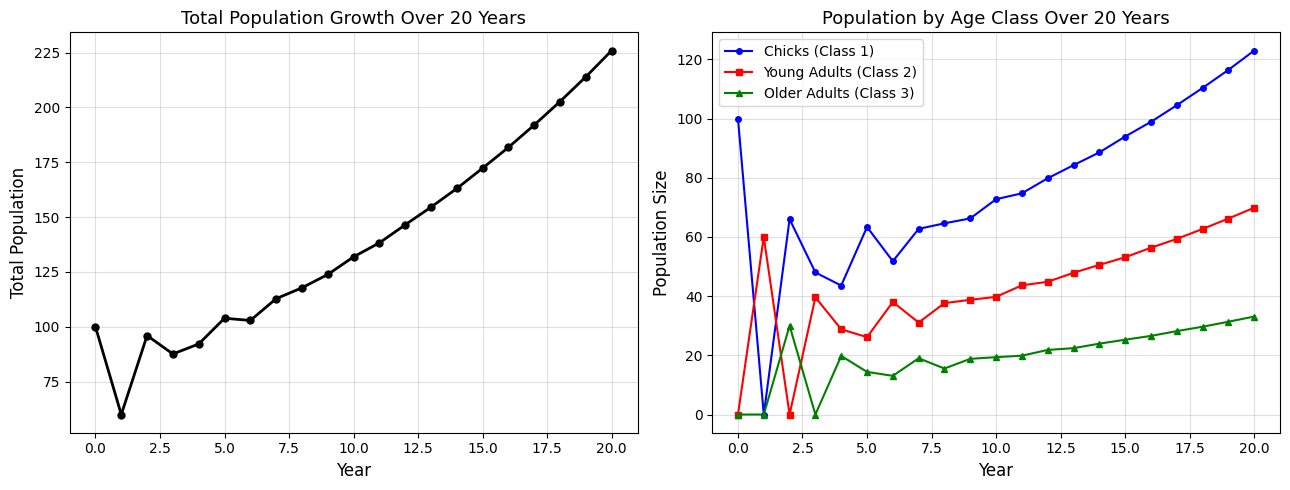

In [21]:
# ---------------------------------------------------------
# Visualise the results
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left plot: Total population over time ---
axes[0].plot(t_arr, total_pop, 'k-o', linewidth=2, markersize=5)
axes[0].set_xlabel("Year", fontsize=12)
axes[0].set_ylabel("Total Population", fontsize=12)
axes[0].set_title("Total Population Growth Over 20 Years", fontsize=13)
axes[0].grid(True, alpha=0.4)

# --- Right plot: Population by age class ---
axes[1].plot(t_arr, pop_history[0, :], 'b-o', label='Chicks (Class 1)',       markersize=4)
axes[1].plot(t_arr, pop_history[1, :], 'r-s', label='Young Adults (Class 2)', markersize=4)
axes[1].plot(t_arr, pop_history[2, :], 'g-^', label='Older Adults (Class 3)', markersize=4)
axes[1].set_xlabel("Year", fontsize=12)
axes[1].set_ylabel("Population Size", fontsize=12)
axes[1].set_title("Population by Age Class Over 20 Years", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## Long-Term Dynamics: Stable Age Distribution and Growth Rate $\lambda$

If we simulate long enough, the population's behaviour converges to a **steady state** in two important senses:

1. **Stable Age Distribution** — the *proportion* of individuals in each age class becomes constant over time, regardless of the initial population vector. This is the eigenvector associated with the dominant eigenvalue.

2. **Asymptotic Growth Rate $\lambda$** — the total population grows (or declines) by a constant factor each time step. This factor is the **dominant eigenvalue** of the Leslie matrix.

| $\lambda$ value | Interpretation |
|-----------------|----------------|
| $\lambda > 1$   | Population grows |
| $\lambda = 1$   | Population is stationary |
| $\lambda < 1$   | Population declines |

We can find $\lambda$ in two complementary ways:
- **Numerically** from the simulation: $\lambda \approx N(t+1) / N(t)$ at large $t$.
- **Analytically** using linear algebra: $\lambda$ is the largest real eigenvalue of $\mathbf{L}$.

In [22]:
# ---------------------------------------------------------
# Part A: Stable Age Distribution from simulation
# ---------------------------------------------------------
# Normalise each time step so proportions sum to 1
proportions = pop_history / total_pop   # Broadcasting divides each column by its total

print("Proportional age structure (rows = age classes, columns = years):")
print(f"{'Year':>4}  {'Chicks':>8}  {'Young':>8}  {'Older':>8}")
print("-" * 36)
for t in [0, 5, 10, 15, 19, 20]:
    p = proportions[:, t]
    print(f"{t:>4}  {p[0]:>8.4f}  {p[1]:>8.4f}  {p[2]:>8.4f}")

print()
print("Notice: by year 20 the proportions have nearly stopped changing.")
print("This is the Stable Age Distribution.")

Proportional age structure (rows = age classes, columns = years):
Year    Chicks     Young     Older
------------------------------------
   0    1.0000    0.0000    0.0000
   5    0.6098    0.2516    0.1386
  10    0.5516    0.3015    0.1469
  15    0.5450    0.3083    0.1467
  19    0.5441    0.3094    0.1465
  20    0.5443    0.3092    0.1465

Notice: by year 20 the proportions have nearly stopped changing.
This is the Stable Age Distribution.


In [23]:
# ---------------------------------------------------------
# Part B: Compute lambda from the simulation
# ---------------------------------------------------------
# At large t the ratio of successive total populations converges to lambda
lambda_sim = total_pop[-1] / total_pop[-2]
print(f"Lambda estimated from simulation (year 20 / year 19): {lambda_sim:.6f}")

Lambda estimated from simulation (year 20 / year 19): 1.055895


In [25]:
# ---------------------------------------------------------
# Part C: Eigenvalue analysis of the Leslie Matrix
# ---------------------------------------------------------
eigenvalues, eigenvectors = np.linalg.eig(L_sim)

print("All eigenvalues of L_sim (may include complex numbers):")
for i, ev in enumerate(eigenvalues):
    print(f"  eigenvalue {i+1}: {ev:.6f}")

print()

# The dominant eigenvalue is the one with the largest real part
dominant_idx    = np.argmax(np.real(eigenvalues))
lambda_eig      = np.real(eigenvalues[dominant_idx])
stable_age_vec  = np.real(eigenvectors[:, dominant_idx])

# Normalise the eigenvector so it sums to 1 (it's a distribution)
stable_age_dist = stable_age_vec / stable_age_vec.sum()

print(f"Dominant eigenvalue (lambda): {lambda_eig:.6f}")
print(f"  --> population grows by a factor of {lambda_eig:.4f} each year")
print(f"  --> or approx. {(lambda_eig - 1)*100:.2f}% per year")
print()
print("Stable Age Distribution (from eigenvector):")
for i, p in enumerate(stable_age_dist):
    print(f"  Class {i+1}: {p:.4f} ({p*100:.1f}%)")

print()
print("Comparison with simulated proportions at t=20:")
for i in range(3):
    print(f"  Class {i+1}: eigenvector = {stable_age_dist[i]:.4f},  simulation = {proportions[i,-1]:.4f}")

All eigenvalues of L_sim (may include complex numbers):
  eigenvalue 1: 1.055768+0.000000j
  eigenvalue 2: -0.527884+0.419505j
  eigenvalue 3: -0.527884-0.419505j

Dominant eigenvalue (lambda): 1.055768
  --> population grows by a factor of 1.0558 each year
  --> or approx. 5.58% per year

Stable Age Distribution (from eigenvector):
  Class 1: 0.5442 (54.4%)
  Class 2: 0.3093 (30.9%)
  Class 3: 0.1465 (14.6%)

Comparison with simulated proportions at t=20:
  Class 1: eigenvector = 0.5442,  simulation = 0.5443
  Class 2: eigenvector = 0.3093,  simulation = 0.3092
  Class 3: eigenvector = 0.1465,  simulation = 0.1465


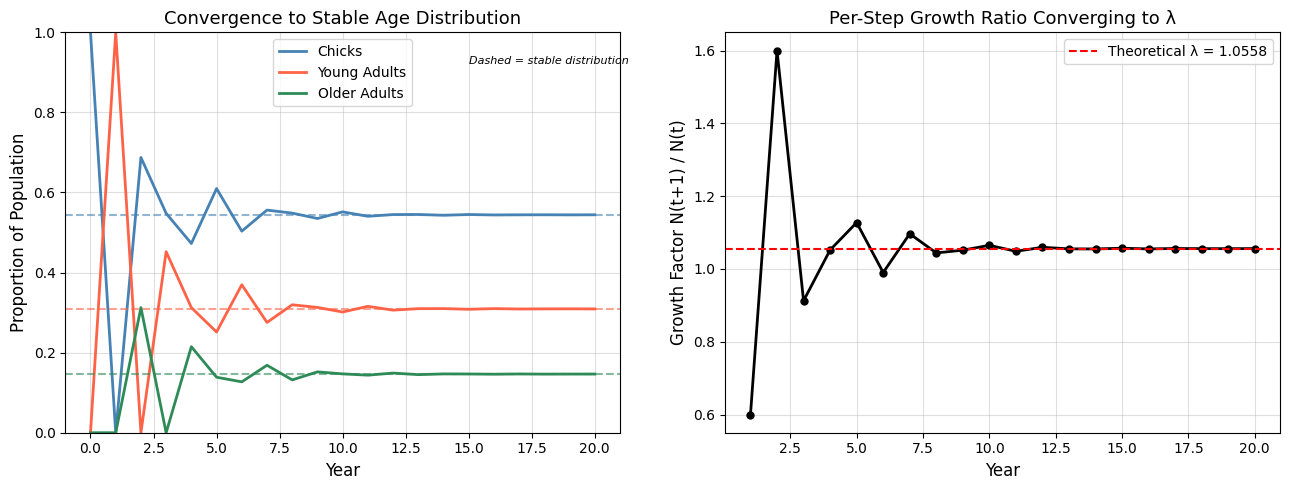

In [26]:
# ---------------------------------------------------------
# Visualise convergence to stable age distribution
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Proportions converging over time ---
labels = ['Chicks', 'Young Adults', 'Older Adults']
colors = ['steelblue', 'tomato', 'seagreen']
for i in range(3):
    axes[0].plot(t_arr, proportions[i, :], color=colors[i],
                 linewidth=2, label=labels[i])
    # Draw the stable age distribution as a dashed horizontal line
    axes[0].axhline(stable_age_dist[i], color=colors[i],
                    linestyle='--', alpha=0.6)

axes[0].set_xlabel("Year", fontsize=12)
axes[0].set_ylabel("Proportion of Population", fontsize=12)
axes[0].set_title("Convergence to Stable Age Distribution", fontsize=13)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)
axes[0].text(15, 0.92, 'Dashed = stable distribution', fontsize=8, style='italic')

# --- Right: Per-step growth factor converging to lambda ---
growth_ratios = total_pop[1:] / total_pop[:-1]   # ratio of consecutive totals
axes[1].plot(t_arr[1:], growth_ratios, 'k-o', markersize=5, linewidth=2)
axes[1].axhline(lambda_eig, color='red', linestyle='--',
                linewidth=1.5, label=f'Theoretical λ = {lambda_eig:.4f}')
axes[1].set_xlabel("Year", fontsize=12)
axes[1].set_ylabel("Growth Factor N(t+1) / N(t)", fontsize=12)
axes[1].set_title("Per-Step Growth Ratio Converging to λ", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## Sensitivity Analysis: Which Parameter Matters Most?

A practical question in conservation or wildlife management is: *if one demographic rate improves slightly, how much does the population growth rate $\lambda$ change?*

**Sensitivity** of $\lambda$ to a parameter $\theta$ is measured as the partial derivative $\partial\lambda / \partial\theta$.

We can approximate this numerically by perturbing each parameter by a small amount $\epsilon$ and measuring the change in $\lambda$:

In [27]:
def compute_lambda(matrix):
    """Return the dominant (real) eigenvalue of a Leslie matrix."""
    eigenvalues = np.linalg.eigvals(matrix)
    return np.max(np.real(eigenvalues))

epsilon = 1e-5   # Small perturbation size
lambda_base = compute_lambda(L_sim)

print(f"Base lambda: {lambda_base:.6f}")
print()
print(f"{'Parameter':>20}  {'Base value':>12}  {'Sensitivity ∂λ/∂θ':>18}")
print("-" * 56)

# Check each non-zero entry of L_sim
param_names = {
    (0, 1): 'f2 (Young Adult fecundity)',
    (0, 2): 'f3 (Older Adult fecundity)',
    (1, 0): 's1 (Chick survival)',
    (2, 1): 's2 (Young Adult survival)',
}

for (row, col), name in param_names.items():
    L_perturbed = L_sim.copy()
    base_val = L_sim[row, col]
    L_perturbed[row, col] += epsilon
    lambda_new = compute_lambda(L_perturbed)
    sensitivity = (lambda_new - lambda_base) / epsilon
    print(f"{name:>30}  {base_val:>10.3f}  {sensitivity:>18.6f}")

Base lambda: 1.055768

           Parameter    Base value   Sensitivity ∂λ/∂θ
--------------------------------------------------------
    f2 (Young Adult fecundity)       1.100            0.236019
    f3 (Older Adult fecundity)       1.600            0.111776
           s1 (Chick survival)       0.600            0.730768
     s2 (Young Adult survival)       0.500            0.357682


> **Interpretation:** A higher sensitivity value means that a small increase in that parameter produces a larger increase in $\lambda$. This tells us which demographic rate is the most influential "lever" for managing the population.

---
## Real-World Case Study: Czech Republic Human Population (2010)

The examples so far have used stylised animal populations. Now let's apply the same framework to a real demographic dataset: the **Czech Republic in 2010**, divided into 20 five-year age groups (0–4, 5–9, …, 90–94, 95+).

Because each age group spans 5 years, we need to **adjust the annual demographic rates** to match the 5-year time step used in the simulation:

- **Survival over 5 years:** $s_{\text{group}} = s_{\text{annual}}^{5}$
- **Fertility over 5 years:** $f_{\text{group}} = f_{\text{annual}} \times 5$

This is a direct application of the same Leslie Matrix machinery, just with $n = 20$ age classes instead of 3.

In [28]:
# =============================================================
# Czech Republic Leslie Matrix Model — 2010 baseline
# =============================================================

# --- Model settings ---
group_interval   = 5      # years per age group
simulation_years = 100    # total years to simulate
initial_year     = 2010

# --- Initial population vector (20 five-year age groups, from age 0 to 95+) ---
population_initial = np.array([
    275413, 228558, 223394, 300086, 339507, 365668,
    450984, 410637, 341023, 333977, 351237, 390758,
    380115, 293910, 212293, 196457, 149630,  84217,
     16110,   5079
], dtype=float)

n = len(population_initial)
print(f"Number of age groups : {n}")
print(f"Total population 2010: {int(population_initial.sum()):,}")

Number of age groups : 20
Total population 2010: 5,349,053


In [29]:
# --- Annual demographic rates ---

# Annual survival rates (one per transition between age groups; 19 values for 20 groups)
survival_annual = np.array([
    0.999354, 0.999891, 0.999888, 0.999783, 0.999747, 0.999751,
    0.999643, 0.999437, 0.998944, 0.998111, 0.996996, 0.995222,
    0.992205, 0.987149, 0.978713, 0.962139, 0.925109, 0.857950,
    0.743265
])

# Annual fertility rates (average live births per woman per year, by age group)
fertility_annual = np.array([
    0.000000, 0.000000, 0.000027, 0.005455, 0.022008, 0.048309,
    0.047481, 0.019136, 0.002915, 0.000117, 0.000006, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000
])

# --- Convert annual rates to 5-year group rates ---
survival_group  = survival_annual ** group_interval   # compound survival over 5 years
fertility_group = fertility_annual * group_interval   # sum fertility over 5 years

print("Adjusted rates for 5-year groups (showing first 10):")
print(f"{'Age group':>10}  {'Annual surv':>12}  {'5-yr surv':>10}  {'Annual fert':>12}  {'5-yr fert':>10}")
print("-" * 62)
for i in range(10):
    s_ann = survival_annual[i] if i < len(survival_annual) else float('nan')
    s_grp = survival_group[i]  if i < len(survival_group)  else float('nan')
    f_ann = fertility_annual[i]
    f_grp = fertility_group[i]
    label = f"{i*5}–{i*5+4}"
    print(f"{label:>10}  {s_ann:>12.6f}  {s_grp:>10.6f}  {f_ann:>12.6f}  {f_grp:>10.6f}")

Adjusted rates for 5-year groups (showing first 10):
 Age group   Annual surv   5-yr surv   Annual fert   5-yr fert
--------------------------------------------------------------
       0–4      0.999354    0.996774      0.000000    0.000000
       5–9      0.999891    0.999455      0.000000    0.000000
     10–14      0.999888    0.999440      0.000027    0.000135
     15–19      0.999783    0.998915      0.005455    0.027275
     20–24      0.999747    0.998736      0.022008    0.110040
     25–29      0.999751    0.998756      0.048309    0.241545
     30–34      0.999643    0.998216      0.047481    0.237405
     35–39      0.999437    0.997188      0.019136    0.095680
     40–44      0.998944    0.994731      0.002915    0.014575
     45–49      0.998111    0.990591      0.000117    0.000585


In [30]:
# --- Build the Czech Leslie Matrix (20 x 20) ---
leslie_cz = np.zeros((n, n))

# First row: fertility rates
leslie_cz[0, :] = fertility_group

# Sub-diagonal: survival rates
for i in range(1, n):
    leslie_cz[i, i - 1] = survival_group[i - 1]

print("Czech Leslie Matrix (20×20) — first 5 rows and columns shown:")
print(np.round(leslie_cz[:5, :5], 6))
print("...")
print()
print("Non-zero entries in the first row (fecundity rates, 5-yr):")
for i, f in enumerate(fertility_group):
    if f > 0:
        print(f"  Age group {i*5}–{i*5+4}: {f:.6f}")

Czech Leslie Matrix (20×20) — first 5 rows and columns shown:
[[0.00000e+00 0.00000e+00 1.35000e-04 2.72750e-02 1.10040e-01]
 [9.96774e-01 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 9.99455e-01 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 9.99440e-01 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 9.98915e-01 0.00000e+00]]
...

Non-zero entries in the first row (fecundity rates, 5-yr):
  Age group 10–14: 0.000135
  Age group 15–19: 0.027275
  Age group 20–24: 0.110040
  Age group 25–29: 0.241545
  Age group 30–34: 0.237405
  Age group 35–39: 0.095680
  Age group 40–44: 0.014575
  Age group 45–49: 0.000585
  Age group 50–54: 0.000030


In [31]:
# --- Run the 100-year simulation ---
simulation_steps = simulation_years // group_interval   # 20 steps of 5 years each

population_by_step = np.zeros((n, simulation_steps + 1))
population_by_step[:, 0] = population_initial

for t in range(1, simulation_steps + 1):
    population_by_step[:, t] = leslie_cz @ population_by_step[:, t - 1]

total_population = population_by_step.sum(axis=0)
year_axis = np.arange(initial_year,
                      initial_year + (simulation_steps + 1) * group_interval,
                      group_interval)

# Print a summary table
print(f"{'Year':>6}  {'Total Population':>18}  {'Change from 2010':>18}")
print("-" * 46)
for i, yr in enumerate(year_axis):
    change = total_population[i] - total_population[0]
    print(f"{yr:>6}  {int(total_population[i]):>18,}  {int(change):>+18,}")

  Year    Total Population    Change from 2010
----------------------------------------------
  2010           5,349,053                  +0
  2015           5,410,777             +61,724
  2020           5,405,611             +56,558
  2025           5,339,169              -9,883
  2030           5,216,612            -132,440
  2035           5,049,380            -299,672
  2040           4,863,720            -485,332
  2045           4,680,386            -668,666
  2050           4,499,702            -849,350
  2055           4,308,358          -1,040,694
  2060           4,094,841          -1,254,211
  2065           3,862,505          -1,486,547
  2070           3,633,221          -1,715,831
  2075           3,430,762          -1,918,290
  2080           3,261,013          -2,088,039
  2085           3,114,409          -2,234,643
  2090           2,977,936          -2,371,116
  2095           2,839,076          -2,509,976
  2100           2,692,796          -2,656,256
  2105       

In [32]:
# --- Compute the long-term growth rate lambda for the Czech model ---
lambda_cz = np.max(np.real(np.linalg.eigvals(leslie_cz)))
# Note: lambda here is per 5-year step, convert to annual
lambda_cz_annual = lambda_cz ** (1 / group_interval)

print(f"Dominant eigenvalue (per 5-yr step) : {lambda_cz:.6f}")
print(f"Equivalent annual growth rate       : {lambda_cz_annual:.6f}")
print()
if lambda_cz < 1:
    print("λ < 1: The Czech population is projected to DECLINE under these 2010 rates.")
elif lambda_cz > 1:
    print("λ > 1: The Czech population is projected to GROW under these 2010 rates.")
else:
    print("λ = 1: The Czech population is projected to remain stationary.")

Dominant eigenvalue (per 5-yr step) : 0.950773
Equivalent annual growth rate       : 0.989955

λ < 1: The Czech population is projected to DECLINE under these 2010 rates.


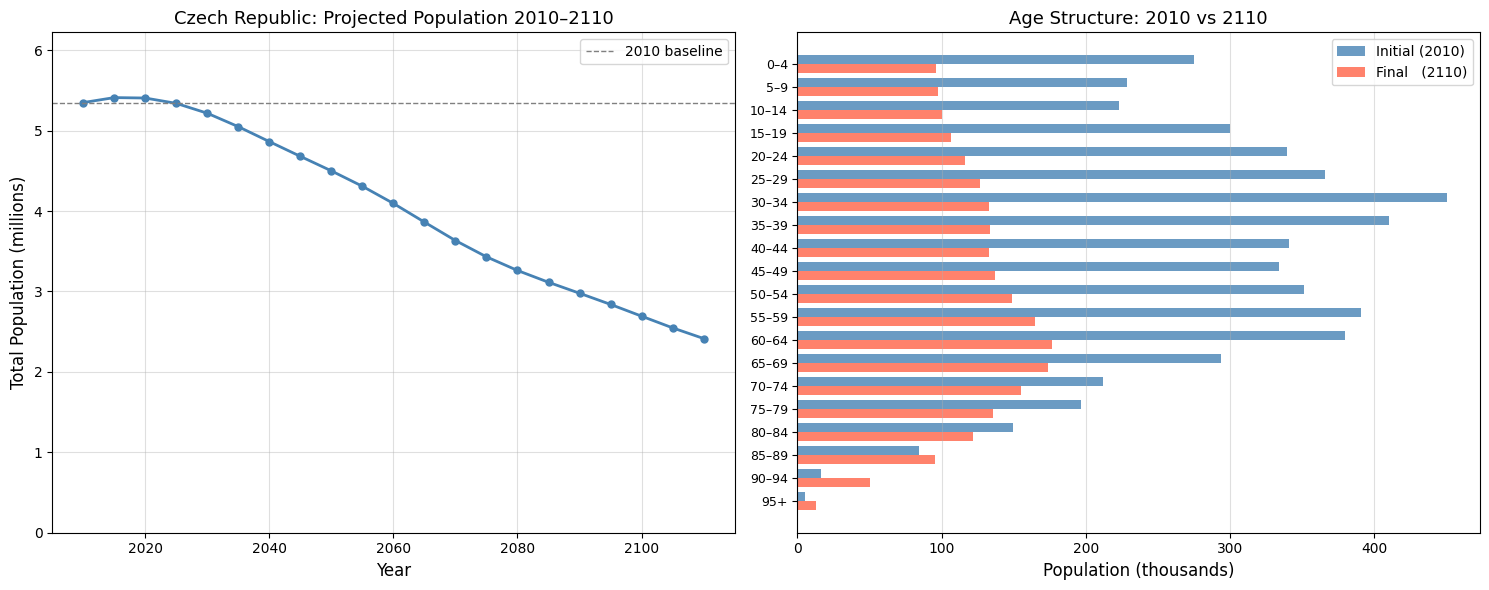

Initial total population : 5,349,053
Final total population   : 2,414,927
Change over 100 years    : -2,934,125


In [34]:
# --- Visualise the Czech model results ---

# Build age group labels for axis ticks
age_labels = [f"{i*group_interval}–{(i+1)*group_interval-1}" for i in range(n - 1)]
age_labels.append(f"{(n-1)*group_interval}+")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Total population trajectory ---
ax1.plot(year_axis, total_population / 1e6, '-o', linewidth=2,
         markersize=5, color='steelblue')
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Total Population (millions)", fontsize=12)
ax1.set_title("Czech Republic: Projected Population 2010–2110", fontsize=13)
ax1.set_ylim(0, total_population.max() / 1e6 * 1.15)
ax1.grid(True, alpha=0.4)
ax1.axhline(total_population[0] / 1e6, color='gray',
            linestyle='--', linewidth=1, label='2010 baseline')
ax1.legend(fontsize=10)

# --- Right: Initial vs final age structure (horizontal bar chart) ---
y_pos     = np.arange(n)
bar_width = 0.4

ax2.barh(y_pos - bar_width / 2, population_by_step[:, 0] / 1e3,
         height=bar_width, color='steelblue', alpha=0.8, label=f"Initial ({initial_year})")
ax2.barh(y_pos + bar_width / 2, population_by_step[:, -1] / 1e3,
         height=bar_width, color='tomato',    alpha=0.8, label=f"Final   ({initial_year + simulation_years})")

ax2.set_yticks(y_pos)
ax2.set_yticklabels(age_labels, fontsize=9)
ax2.invert_yaxis()   # youngest at top
ax2.set_xlabel("Population (thousands)", fontsize=12)
ax2.set_title("Age Structure: 2010 vs 2110", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Initial total population : {int(total_population[0]):,}")
print(f"Final total population   : {int(total_population[-1]):,}")
print(f"Change over 100 years    : {int(total_population[-1] - total_population[0]):+,}")

---
## Summary

In this notebook we have covered the full Leslie Matrix workflow:

1. **Theory** — age-structured models, fecundity, survival, and the projection equation $\mathbf{n}_{t+1} = \mathbf{L}\,\mathbf{n}_t$.
2. **Construction** — building the Leslie matrix from demographic parameters, step by step.
3. **Simulation** — iterating the projection to observe population trajectories.
4. **Eigenanalysis** — computing $\lambda$ and the stable age distribution analytically, and confirming that the simulation converges to these theoretical values.
5. **Sensitivity analysis** — identifying which demographic rates most influence population growth.
6. **Real-world application** — applying the model to Czech Republic data, including the conversion of annual rates to multi-year group rates.

### Extensions of the model

The Leslie Matrix framework can be extended in many directions:
- **Density dependence** — let survival/fecundity rates depend on current population size.
- **Stochasticity** — introduce random variation in demographic rates.
- **Stage-structured models (Lefkovitch matrices)** — replace age classes with life-history stages.
- **Time-varying rates** — update $\mathbf{L}$ at each step to reflect changing conditions.

Despite its simplicity, the linear Leslie Matrix model remains a cornerstone of population ecology, demography, and conservation biology.